In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import sys
print(sys.executable)

C:\Users\KEJU\AppData\Local\Programs\Python\Python310\python.exe


In [3]:
upi = pd.read_excel('E:\\project_upi_pulse\\data\\upi_raw.xlsx')
festive = pd.read_excel('E:\\project_upi_pulse\\data\\festive_calendar.xlsx')
print("UPI Data Shape:", upi.shape)
print("Festive Data Shape:", festive.shape)
print("\n--- UPI First 5 Rows ---")
print(upi.head())
print("\n--- Festive First 5 Rows ---")
print(festive.head())

UPI Data Shape: (83, 3)
Festive Data Shape: (45, 3)

--- UPI First 5 Rows ---
           Month  Volume (In Mn.)  Value (In Cr.)
0     March-2020          1246.84       206462.31
1  February-2020          1325.69       222516.95
2   January-2020          1305.02       216242.97
3  December-2019          1308.40       202520.76
4  November-2019          1218.77       189229.09

--- Festive First 5 Rows ---
  Month  Year        Festival
0   Oct  2019          Diwali
1   Mar  2019            Holi
2   Jun  2019     Eid-ul-Fitr
3  Sept  2019       Navaratri
4   Aug  2019  Raksha Bandhan


In [4]:
upi.columns = ['month_year', 'upi_volume_mn', 'upi_value_cr']
festive.columns = ['month', 'year', 'festival']
print("UPI columns:", upi.columns.tolist())
print("Festive columns:", festive.columns.tolist())

UPI columns: ['month_year', 'upi_volume_mn', 'upi_value_cr']
Festive columns: ['month', 'year', 'festival']


In [5]:
upi['date'] = pd.to_datetime(upi['month_year'], format='%B-%Y')
upi['month'] = upi['date'].dt.strftime('%b')
upi['year'] = upi['date'].dt.year
upi = upi.drop(columns=['month_year'])
upi = upi.sort_values('date').reset_index(drop=True)
upi = upi[['date', 'month', 'year', 'upi_volume_mn', 'upi_value_cr']]
print("Date range:", upi['date'].min(), "to", upi['date'].max())
print("Total rows:", len(upi))
print("\nFirst 5 rows:")
upi.head()

Date range: 2019-04-01 00:00:00 to 2026-02-01 00:00:00
Total rows: 83

First 5 rows:


,date,month,year,upi_volume_mn,upi_value_cr
0,2019-04-01,Apr,2019,781.79,142034.39
1,2019-05-01,May,2019,733.54,152449.29
2,2019-06-01,Jun,2019,754.54,146566.35
3,2019-07-01,Jul,2019,822.29,146386.64
4,2019-08-01,Aug,2019,918.35,154504.89


In [6]:
print("=== Missing Values Check ===")
print(upi.isnull().sum())
print("\n=== Data Types ===")
print(upi.dtypes)
print("\n=== Basic Statistics ===")
print(upi[['upi_volume_mn', 'upi_value_cr']].describe())

=== Missing Values Check ===
date             0
month            0
year             0
upi_volume_mn    0
upi_value_cr     0
dtype: int64

=== Data Types ===
date             datetime64[ns]
month                    object
year                      int32
upi_volume_mn           float64
upi_value_cr            float64
dtype: object

=== Basic Statistics ===
       upi_volume_mn  upi_value_cr
count      83.000000  8.300000e+01
mean     8440.235542  1.242125e+06
std      6678.341536  8.612282e+05
min       733.540000  1.420344e+05
25%      2263.530000  4.206195e+05
50%      6780.800000  1.116438e+06
75%     13960.490000  2.026009e+06
max     21703.440000  2.833481e+06


In [7]:
festive['month'] = festive['month'].str.replace('Sept', 'Sep')
print('Festive month names after fix:')
print(festive['month'].unique())

Festive month names after fix:
['Oct' 'Mar' 'Jun' 'Sep' 'Aug' 'Dec' 'Nov' 'May' 'Apr']


In [8]:
festival_priority = {'Diwali': 1, 'Holi': 2, 'Eid-ul-Fitr': 3, 'Navaratri': 4, 'Raksha Bandhan': 5, 'Christmas': 6}
festive['priority'] = festive['festival'].map(festival_priority)
festive = festive.sort_values(['month', 'year', 'priority'])
festive = festive.drop_duplicates(subset=['month', 'year'], keep='first')
festive = festive.drop(columns=['priority'])
print("Festive calendar after fix:")
print(f"Total rows: {len(festive)}")
print(festive.to_string())

Festive calendar after fix:
Total rows: 42
   month  year        festival
26   Apr  2023     Eid-ul-Fitr
32   Apr  2024     Eid-ul-Fitr
4    Aug  2019  Raksha Bandhan
10   Aug  2020  Raksha Bandhan
16   Aug  2021  Raksha Bandhan
22   Aug  2022  Raksha Bandhan
28   Aug  2023  Raksha Bandhan
34   Aug  2024  Raksha Bandhan
40   Aug  2025  Raksha Bandhan
5    Dec  2019       Christmas
11   Dec  2020       Christmas
17   Dec  2021       Christmas
23   Dec  2022       Christmas
29   Dec  2023       Christmas
35   Dec  2024       Christmas
41   Dec  2025       Christmas
2    Jun  2019     Eid-ul-Fitr
1    Mar  2019            Holi
7    Mar  2020            Holi
13   Mar  2021            Holi
19   Mar  2022            Holi
25   Mar  2023            Holi
31   Mar  2024            Holi
37   Mar  2025            Holi
43   Mar  2026            Holi
8    May  2020     Eid-ul-Fitr
14   May  2021     Eid-ul-Fitr
20   May  2022     Eid-ul-Fitr
6    Nov  2020          Diwali
12   Nov  2021          Diw

In [9]:
upi = upi.merge(festive, on=['month', 'year'], how='left')
upi['is_festive'] = upi['festival'].notna().astype(int)
print('Total festive months found:', upi['is_festive'].sum())
print('Total non-festive months:', (upi['is_festive'] == 0).sum())
print("\nFestive months detail:")
print(upi[upi['is_festive'] == 1][['date', 'month', 'year', 'festival']].to_string())

Total festive months found: 39
Total non-festive months: 44

Festive months detail:
         date month  year        festival
2  2019-06-01   Jun  2019     Eid-ul-Fitr
4  2019-08-01   Aug  2019  Raksha Bandhan
5  2019-09-01   Sep  2019       Navaratri
6  2019-10-01   Oct  2019          Diwali
8  2019-12-01   Dec  2019       Christmas
11 2020-03-01   Mar  2020            Holi
13 2020-05-01   May  2020     Eid-ul-Fitr
16 2020-08-01   Aug  2020  Raksha Bandhan
18 2020-10-01   Oct  2020       Navaratri
19 2020-11-01   Nov  2020          Diwali
20 2020-12-01   Dec  2020       Christmas
23 2021-03-01   Mar  2021            Holi
25 2021-05-01   May  2021     Eid-ul-Fitr
28 2021-08-01   Aug  2021  Raksha Bandhan
30 2021-10-01   Oct  2021       Navaratri
31 2021-11-01   Nov  2021          Diwali
32 2021-12-01   Dec  2021       Christmas
35 2022-03-01   Mar  2022            Holi
37 2022-05-01   May  2022     Eid-ul-Fitr
40 2022-08-01   Aug  2022  Raksha Bandhan
41 2022-09-01   Sep  2022       Na

In [10]:
upi['vol_mom_growth'] = upi['upi_volume_mn'].pct_change() * 100
upi['vol_yoy_growth'] = upi['upi_volume_mn'].pct_change(12) * 100
upi['avg_ticket_size'] = (upi['upi_value_cr'] * 1e7) / (upi['upi_volume_mn'] * 1e6)
upi['vol_3m_avg'] = upi['upi_volume_mn'].rolling(3).mean()
upi['ticket_6m_avg'] = upi['avg_ticket_size'].rolling(6).mean()
print("New columns added successfully!")
print("\nSample of engineered features:")
upi[['date', 'avg_ticket_size', 'vol_mom_growth', 'vol_yoy_growth']].head(10)

New columns added successfully!

Sample of engineered features:


,date,avg_ticket_size,vol_mom_growth,vol_yoy_growth
0,2019-04-01,1816.784431,NaN,NaN
1,2019-05-01,2078.268261,-6.171734,NaN
2,2019-06-01,1942.459644,2.862830,NaN
3,2019-07-01,1780.231305,8.978981,NaN
4,2019-08-01,1682.418359,11.682010,NaN
5,2019-09-01,1690.609202,3.993031,NaN
6,2019-10-01,1666.375875,20.244602,NaN
7,2019-11-01,1552.623465,6.131353,NaN
8,2019-12-01,1547.850504,7.354136,NaN
9,2020-01-01,1657.008858,-0.258331,NaN


In [11]:
upi['ticket_zscore'] = ((upi['avg_ticket_size'] - upi['ticket_6m_avg']) / upi['avg_ticket_size'].rolling(6).std())
upi['volume_zscore'] = ((upi['upi_volume_mn'] - upi['vol_3m_avg']) / upi['upi_volume_mn'].rolling(6).std())
upi['psi_raw'] = (upi['volume_zscore'] * 0.55 + (-upi['ticket_zscore']) * 0.45)
psi_min = upi['psi_raw'].min()
psi_max = upi['psi_raw'].max()
upi['psi_score'] = ((upi['psi_raw'] - psi_min) / (psi_max - psi_min)) * 100
print("PSI Score range:", round(upi['psi_score'].min(), 2), "to", round(upi['psi_score'].max(), 2))
print("\nTop 5 highest stress months:")
print(upi[['date', 'psi_score', 'festival']].nlargest(5, 'psi_score').to_string())

PSI Score range: 0.0 to 100.0

Top 5 highest stress months:
         date   psi_score        festival
35 2022-03-01  100.000000            Holi
59 2024-03-01   94.401423            Holi
64 2024-08-01   93.690428  Raksha Bandhan
71 2025-03-01   92.922674            Holi
76 2025-08-01   92.031030  Raksha Bandhan


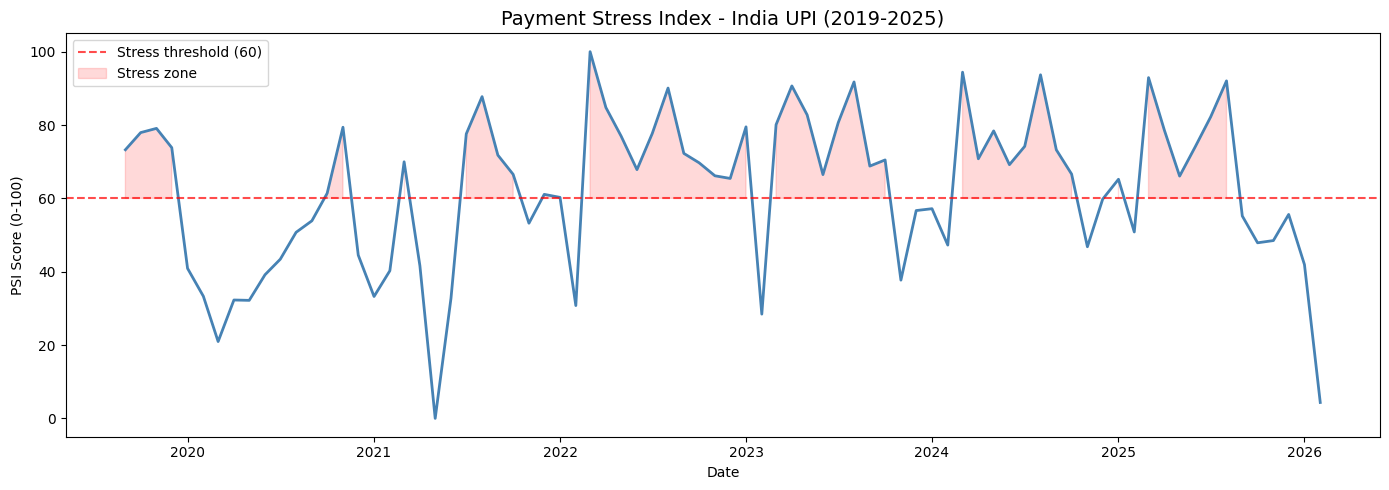

Chart saved as psi_chart.png


In [12]:
plt.figure(figsize=(14, 5))
plt.plot(upi['date'], upi['psi_score'], color='steelblue', linewidth=2)
plt.axhline(y=60, color='red', linestyle='--', alpha=0.7, label='Stress threshold (60)')
plt.fill_between(upi['date'], upi['psi_score'], 60, where=(upi['psi_score'] > 60), color='red', alpha=0.15, label='Stress zone')
plt.title('Payment Stress Index - India UPI (2019-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('PSI Score (0-100)')
plt.legend()
plt.tight_layout()
plt.savefig('psi_chart.png', dpi=150)
plt.show()
print('Chart saved as psi_chart.png')

In [13]:
upi_final = upi.drop(columns=['psi_raw', 'ticket_zscore', 'volume_zscore', 'ticket_6m_avg'])
print("Final columns for power BI:")
print(upi_final.columns.tolist())
print("\nFinal shape:", upi_final.shape)
print("\nFirst 5 rows of final data:")
upi_final.head()

Final columns for power BI:
['date', 'month', 'year', 'upi_volume_mn', 'upi_value_cr', 'festival', 'is_festive', 'vol_mom_growth', 'vol_yoy_growth', 'avg_ticket_size', 'vol_3m_avg', 'psi_score']

Final shape: (83, 12)

First 5 rows of final data:


,date,month,year,upi_volume_mn,upi_value_cr,festival,is_festive,vol_mom_growth,vol_yoy_growth,avg_ticket_size,vol_3m_avg,psi_score
0,2019-04-01,Apr,2019,781.79,142034.39,NaN,0,NaN,NaN,1816.784431,NaN,NaN
1,2019-05-01,May,2019,733.54,152449.29,NaN,0,-6.171734,NaN,2078.268261,NaN,NaN
2,2019-06-01,Jun,2019,754.54,146566.35,Eid-ul-Fitr,1,2.862830,NaN,1942.459644,756.623333,NaN
3,2019-07-01,Jul,2019,822.29,146386.64,NaN,0,8.978981,NaN,1780.231305,770.123333,NaN
4,2019-08-01,Aug,2019,918.35,154504.89,Raksha Bandhan,1,11.682010,NaN,1682.418359,831.726667,NaN


In [14]:
duplicates = upi_final[upi_final.duplicated(subset=['date'], keep=False)]
print("Duplicate dates found:")
print(duplicates[['date', 'month', 'year', 'festival']].to_string())

Duplicate dates found:
Empty DataFrame
Columns: [date, month, year, festival]
Index: []


In [15]:
upi_final.to_csv('E:\\project_upi_pulse\\data\\upi_cleaned.csv', index=False)
print("File saved successfully!")
print("Location: E:\\project_upi_pulse\\data\\upi_cleaned.csv")
print(f"Total rows: {len(upi_final)}")
print(f"Total columns: {len(upi_final.columns)}")
print(f"\nColumns saved:")
print(upi_final.columns.tolist())

File saved successfully!
Location: E:\project_upi_pulse\data\upi_cleaned.csv
Total rows: 83
Total columns: 12

Columns saved:
['date', 'month', 'year', 'upi_volume_mn', 'upi_value_cr', 'festival', 'is_festive', 'vol_mom_growth', 'vol_yoy_growth', 'avg_ticket_size', 'vol_3m_avg', 'psi_score']
